In [1]:
import pandas as pd

In [2]:
train_df = pd.read_csv('../results/outputs/Selected/train_top10_features.csv')
test_df = pd.read_csv('../results/outputs/Selected/test_top10_features.csv')

In [3]:
train_df_pca = pd.read_csv('../results/outputs/PCA/pca_train.csv')
test_df_pca = pd.read_csv('../results/outputs/PCA/pca_test.csv')

In [4]:
print(test_df.shape)
print(train_df.shape)

(220, 11)
(880, 11)


In [5]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score

In [6]:
feature_cols = [c for c in train_df.columns if c != "target"]

x_train = train_df[feature_cols]
y_train = train_df["target"]

x_test = test_df[feature_cols]
y_test = test_df["target"]

In [7]:
knn = KNeighborsClassifier()
knn.fit(x_train, y_train)

knn_preds = knn.predict(x_test)
knn_accuracy = accuracy_score(y_test, knn_preds)

print("KNN Accuracy:", knn_accuracy)
print(classification_report(y_test, knn_preds))

KNN Accuracy: 0.8909090909090909
              precision    recall  f1-score   support

           0       0.90      0.88      0.89        74
           1       0.92      0.92      0.92        72
           2       0.86      0.88      0.87        74

    accuracy                           0.89       220
   macro avg       0.89      0.89      0.89       220
weighted avg       0.89      0.89      0.89       220



In [8]:
feature_cols_pca = [c for c in train_df_pca.columns if c != "target"]

x_train_pca = train_df_pca[feature_cols_pca]
y_train_pca = train_df_pca["target"]

x_test_pca = test_df_pca[feature_cols_pca]
y_test_pca = test_df_pca["target"]

knn_pca = KNeighborsClassifier()
knn_pca.fit(x_train_pca, y_train_pca)

knn_preds_pca = knn_pca.predict(x_test_pca)
knn_accuracy_pca = accuracy_score(y_test_pca, knn_preds_pca)

knn_preds_pca_t = knn_pca.predict(x_train_pca) 
knn_accuracy_pca_train = accuracy_score(y_train_pca, knn_preds_pca_t)

print("KNN PCA Test Accuracy:", knn_accuracy_pca)
print("KNN PCA Training Accuracy:", knn_accuracy_pca_train)
print(classification_report(y_test_pca, knn_preds_pca))

KNN PCA Test Accuracy: 0.8727272727272727
KNN PCA Training Accuracy: 0.9159090909090909
              precision    recall  f1-score   support

           0       0.88      0.85      0.86        74
           1       0.87      0.90      0.88        72
           2       0.88      0.86      0.87        74

    accuracy                           0.87       220
   macro avg       0.87      0.87      0.87       220
weighted avg       0.87      0.87      0.87       220



In [9]:
#No overfitting or underfitting goin on

In [10]:
#PCA data dosent show increase in accuracy so continue with the selected features data

In [11]:
#Hyperparameter tuning KNN

In [12]:
from sklearn.model_selection import GridSearchCV

In [13]:
knn_param_grid = {
    'n_neighbors': [3,5,7,9,11,13,15,17,19,21],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski', 'hamming']
}

In [14]:
grid_knn = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=knn_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_knn.fit(x_train, y_train)

print("Best KNN parameters:", grid_knn.best_params_)
print("Best KNN CV accuracy:", grid_knn.best_score_)

Fitting 5 folds for each of 80 candidates, totalling 400 fits


Best KNN parameters: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}
Best KNN CV accuracy: 0.8886363636363637


In [15]:
best_knn = grid_knn.best_estimator_
tuned_knn_preds = best_knn.predict(x_test)
tuned_knn_accuracy = accuracy_score(y_test, tuned_knn_preds)

print("Tuned KNN Test Accuracy for Test Data:", tuned_knn_accuracy)
print(classification_report(y_test, tuned_knn_preds))

tuned_knn_preds_t = best_knn.predict(x_train)
tuned_knn_accuracy_t = accuracy_score(y_train, tuned_knn_preds_t)

print("Tuned KNN Test Accuracy for Training Data:", tuned_knn_accuracy_t)
print(classification_report(y_train, tuned_knn_preds_t))

Tuned KNN Test Accuracy for Test Data: 0.8909090909090909
              precision    recall  f1-score   support

           0       0.94      0.82      0.88        74
           1       0.86      0.94      0.90        72
           2       0.88      0.91      0.89        74

    accuracy                           0.89       220
   macro avg       0.89      0.89      0.89       220
weighted avg       0.89      0.89      0.89       220

Tuned KNN Test Accuracy for Training Data: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       299
           1       1.00      1.00      1.00       286
           2       1.00      1.00      1.00       295

    accuracy                           1.00       880
   macro avg       1.00      1.00      1.00       880
weighted avg       1.00      1.00      1.00       880



In [ ]:
#So the traned model has a risk of overfitting with training accuracy being 100%
#TO futher fix this doing hyper prameter tuning again with f1-macro as scoring metric
# Also Drop Hamming

In [ ]:
knn_param_grid = {
    'n_neighbors': [3,5,7,9,11,13,15,17,19,21],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

grid_knn = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=knn_param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

grid_knn.fit(x_train, y_train)

print("Best KNN parameters:", grid_knn.best_params_)
print("Best KNN CV accuracy:", grid_knn.best_score_)

res = pd.DataFrame(grid_knn.cv_results_)
res['gap'] = res['mean_train_score'] - res['mean_test_score']

best_row = res.loc[res['mean_test_score'].idxmax()]
cand = res[res['mean_test_score'] >= best_row['mean_test_score'] - best_row['std_test_score']]
choice = cand.sort_values(['gap', 'param_n_neighbors'], ascending=[True, False]).iloc[0]
print("Chosen params:", choice['params'])

final_knn = KNeighborsClassifier(**choice['params']).fit(x_train, y_train)
print("Train:", final_knn.score(x_train, y_train), "Test:", final_knn.score(x_test, y_test))

Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best KNN parameters: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}
Best KNN CV accuracy: 0.8888546375897135
Chosen params: {'metric': 'euclidean', 'n_neighbors': 19, 'weights': 'uniform'}
Train: 0.8897727272727273 Test: 0.8772727272727273


In [ ]:
#Since this gives less accuracy use tuned one eeven with training accuracy being 100%

In [18]:
import joblib

joblib.dump(best_knn, "../results/model_trained_files/knn_model.pkl")

['../results/model_trained_files/knn_model.pkl']

In [19]:
#Visualizing

In [20]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.inspection import DecisionBoundaryDisplay

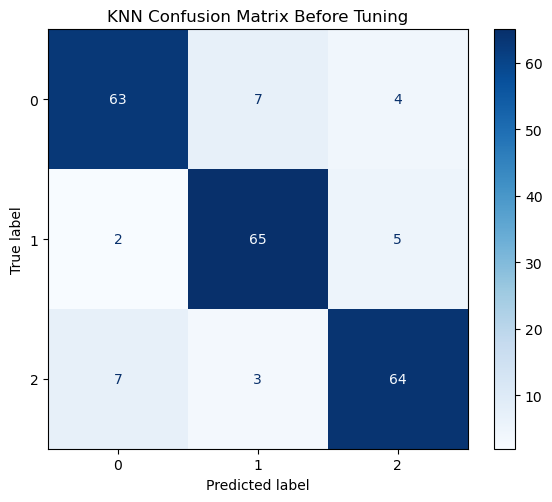

In [21]:
#Before tuning

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test_pca,
    knn_preds_pca,
    cmap="Blues",
    ax=ax
)
ax.set_title("KNN Confusion Matrix Before Tuning")
plt.tight_layout()
plt.show()

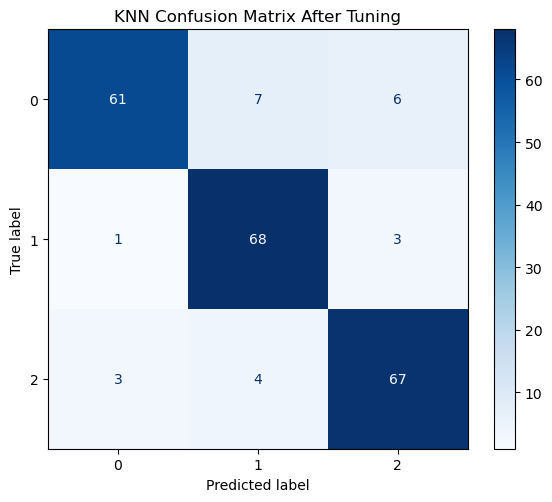

In [22]:
#After tuning

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test_pca,
    tuned_knn_preds,
    cmap="Blues",
    ax=ax
)
ax.set_title("KNN Confusion Matrix After Tuning")
plt.tight_layout()
plt.show()